# =============================================================================
# PROJECT 33: NAIVE BAYES WITH TF-IDF FOR SMS SPAM DETECTION
# By: Omar Sameh Mahmoud 25017251 , Ali Elsayed Ali 2400070 , Mohamed Al-hady Ahmed 2300313
# =============================================================================
# Objectives:
# - Implement Multinomial Naive Bayes with TF-IDF vectorization
# - Compare against classical ML methods (SVM, Decision Tree, KNN)
# - Handle class imbalance, perform ablation studies, error analysis
# =============================================================================

In [14]:
# Cell 1: Environment Setup & Dependencies
# Installs required packages and imports all necessary libraries.

!pip install nltk scikit-learn pandas matplotlib seaborn -q

import pandas as pd
import numpy as np
import re
import os
import matplotlib.pyplot as plt
import seaborn as sns
import nltk

from nltk.stem import PorterStemmer
from nltk.corpus import stopwords
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

# Set global random seed for full reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Download NLTK datasets required for text preprocessing
nltk.download('stopwords', quiet=True)
nltk.download('punkt', quiet=True)

print("✅ Setup complete: All dependencies installed and imported successfully.")

✅ Setup complete: All dependencies installed and imported successfully.


In [34]:
# Cell 2: Dataset Download and Loading
# Downloads the UCI SMS Spam Collection dataset using Python libraries.

import urllib.request
import zipfile
import os
import pandas as pd

# Download the dataset using urllib (works on all platforms)
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00228/smsspamcollection.zip"
filename = "smsspamcollection.zip"

if not os.path.exists(filename):
    print("Downloading dataset...")
    urllib.request.urlretrieve(url, filename)
    print("Download complete.")
else:
    print("Dataset already downloaded.")

# Extract the zip file using zipfile module
if not os.path.exists("SMSSpamCollection"):
    print("Extracting files...")
    with zipfile.ZipFile(filename, 'r') as zip_ref:
        zip_ref.extractall(".")
    print("Extraction complete.")
else:
    print("Dataset already extracted.")

# Load dataset
df = pd.read_csv('SMSSpamCollection', sep='\t', names=['label', 'message'])
df['label'] = df['label'].map({'ham': 0, 'spam': 1})

print(f"Dataset loaded: {df.shape[0]} messages, {df.shape[1]} columns")
print(f"Class distribution:\n{df['label'].value_counts()}")
print(f"Spam ratio: {df['label'].mean()*100:.2f}%")

Dataset already downloaded.
Dataset already extracted.
Dataset loaded: 5572 messages, 2 columns
Class distribution:
label
0    4825
1     747
Name: count, dtype: int64
Spam ratio: 13.41%


In [37]:
# Cell 3: Text Preprocessing Pipeline
# Applies standard NLP cleaning: lowercase, punctuation/number removal, stopword filtering, stemming.
# Ensures consistent input format for feature extraction.

stemmer = PorterStemmer()
stop_words = set(stopwords.words('english'))

def preprocess_text(text):
    text = text.lower()
    text = re.sub(r'[^a-z\s]', ' ', text)
    tokens = text.split()
    tokens = [stemmer.stem(t) for t in tokens if t not in stop_words]
    return ' '.join(tokens)

df['clean'] = df['message'].apply(preprocess_text)

print(f"Cleaned Dataset shape: {df.shape}")  # Updated df.shape

# Save cleaned (trimmed) messages to a text file
output_file = "clean_messages.txt"

with open(output_file, "w", encoding="utf-8") as f:
    for msg in df['clean']:
        if msg.strip():  # avoid empty lines
            f.write(msg.strip() + "\n")

print(f"✅ Clean messages saved to {output_file}")
print(f"✅ Text preprocessing complete.")

Cleaned Dataset shape: (5572, 3)
✅ Clean messages saved to clean_messages.txt
✅ Text preprocessing complete.


In [38]:
# Cell 4: Train-Test Split & Feature Extraction
# Uses stratified sampling to preserve class imbalance in both sets.
# Implements TF-IDF (primary method) and Bag-of-Words (baseline comparison).

X_train, X_test, y_train, y_test = train_test_split(
    df['clean'], df['label'], test_size=0.2, random_state=RANDOM_STATE, stratify=df['label']
)
print(f"📈 Train size: {len(X_train)}, Test size: {len(X_test)}")

# TF-IDF Vectorization (Recommended per project methodology)
tfidf = TfidfVectorizer(max_features=3000, sublinear_tf=True)
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)
print(f"🔹 TF-IDF features: {X_train_tfidf.shape[1]}")

# Bag-of-Words Baseline
bow = CountVectorizer(max_features=3000)
X_train_bow = bow.fit_transform(X_train)
X_test_bow = bow.transform(X_test)
print(f"🔹 BoW features: {X_train_bow.shape[1]}")

📈 Train size: 4457, Test size: 1115
🔹 TF-IDF features: 3000
🔹 BoW features: 3000


In [39]:
# Cell 5: Multinomial Naive Bayes (TF-IDF) Training & Evaluation
# Trains the primary classifier with Laplace smoothing (alpha=1.0).
# Evaluates using standard classification metrics for imbalanced text data.

nb_tfidf = MultinomialNB(alpha=1.0)
nb_tfidf.fit(X_train_tfidf, y_train)
y_pred_nb = nb_tfidf.predict(X_test_tfidf)

print("\n=== Naive Bayes (TF-IDF) Performance ===")
print(f"Accuracy:  {accuracy_score(y_test, y_pred_nb):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_nb):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_nb):.4f}")
print(f"F1-Score:  {f1_score(y_test, y_pred_nb):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_nb, target_names=['Ham', 'Spam']))


=== Naive Bayes (TF-IDF) Performance ===
Accuracy:  0.9758
Precision: 0.9919
Recall:    0.8255
F1-Score:  0.9011

Classification Report:
              precision    recall  f1-score   support

         Ham       0.97      1.00      0.99       966
        Spam       0.99      0.83      0.90       149

    accuracy                           0.98      1115
   macro avg       0.98      0.91      0.94      1115
weighted avg       0.98      0.98      0.97      1115



In [40]:
# Cell 6: Baseline Comparison & Alternative Models
# Compares TF-IDF vs BoW for Naive Bayes to validate feature engineering choice.
# Evaluates SVM, Decision Tree, and KNN with balanced class weights.

print("=== Baseline: BoW vs TF-IDF ===")
nb_bow = MultinomialNB(alpha=1.0)
nb_bow.fit(X_train_bow, y_train)
print(f"NB + BoW Accuracy:  {accuracy_score(y_test, nb_bow.predict(X_test_bow)):.4f}")
print(f"NB + TF-IDF Accuracy: {accuracy_score(y_test, y_pred_nb):.4f}")

print("\n=== Model Comparison (All trained on TF-IDF) ===")
models = {
    'SVM': SVC(kernel='linear', class_weight='balanced', random_state=RANDOM_STATE, probability=True),
    'Decision Tree': DecisionTreeClassifier(class_weight='balanced', random_state=RANDOM_STATE),
    'KNN': KNeighborsClassifier(n_neighbors=5)
}

for name, model in models.items():
    model.fit(X_train_tfidf, y_train)
    preds = model.predict(X_test_tfidf)
    print(f"{name:<15} | Accuracy: {accuracy_score(y_test, preds):.4f} | F1: {f1_score(y_test, preds):.4f}")

=== Baseline: BoW vs TF-IDF ===
NB + BoW Accuracy:  0.9821
NB + TF-IDF Accuracy: 0.9758

=== Model Comparison (All trained on TF-IDF) ===
SVM             | Accuracy: 0.9830 | F1: 0.9347
Decision Tree   | Accuracy: 0.9561 | F1: 0.8464
KNN             | Accuracy: 0.9202 | F1: 0.5742


=== Alpha Sensitivity Analysis ===
Alpha=0.1 | Acc: 0.9821 | F1: 0.9291
Alpha=0.5 | Acc: 0.9794 | F1: 0.9170
Alpha=1.0 | Acc: 0.9758 | F1: 0.9011
Alpha=2.0 | Acc: 0.9632 | F1: 0.8405
Alpha=5.0 | Acc: 0.9283 | F1: 0.6330


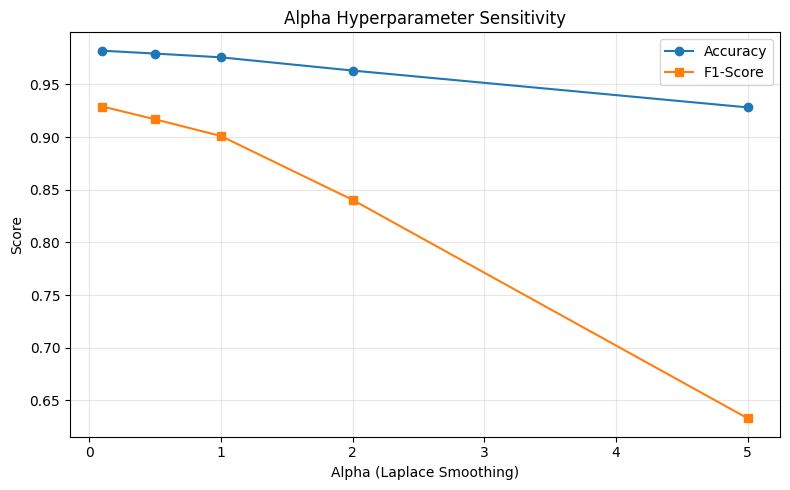

✅ Ablation plot saved as 'alpha_ablation.png'


In [41]:
# Cell 7: Ablation Study - Alpha Hyperparameter Sensitivity
# Tests 5 different smoothing values (exceeds the minimum 3 requirement).
# Plots Accuracy and F1-Score to demonstrate model robustness.

alphas = [0.1, 0.5, 1.0, 2.0, 5.0]
acc_scores, f1_scores = [], []

print("=== Alpha Sensitivity Analysis ===")
for a in alphas:
    model = MultinomialNB(alpha=a)
    model.fit(X_train_tfidf, y_train)
    preds = model.predict(X_test_tfidf)
    acc_scores.append(accuracy_score(y_test, preds))
    f1_scores.append(f1_score(y_test, preds))
    print(f"Alpha={a:.1f} | Acc: {acc_scores[-1]:.4f} | F1: {f1_scores[-1]:.4f}")

plt.figure(figsize=(8, 5))
plt.plot(alphas, acc_scores, marker='o', label='Accuracy')
plt.plot(alphas, f1_scores, marker='s', label='F1-Score')
plt.title('Alpha Hyperparameter Sensitivity')
plt.xlabel('Alpha (Laplace Smoothing)')
plt.ylabel('Score')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig('alpha_ablation.png', dpi=150)
plt.show()
print("✅ Ablation plot saved as 'alpha_ablation.png'")

🔍 False Negatives (Missed Spam): 26
False Negative Rate: 17.45%
Sample missed messages:
1. freemsg hey darl week word back like fun still tb ok xxx std chg send rcv
2. guess somebodi know secretli fanci wanna find give us call landlin datebox essexcm xn p min
3. talk sexi make new friend fall love world discreet text date servic text vip see could meet
4. hi ur lookin sauci daytim fun wiv busti marri woman free next week chat sort time janinexx call minmobsmorelkpobox hp fl
5. ringtonek


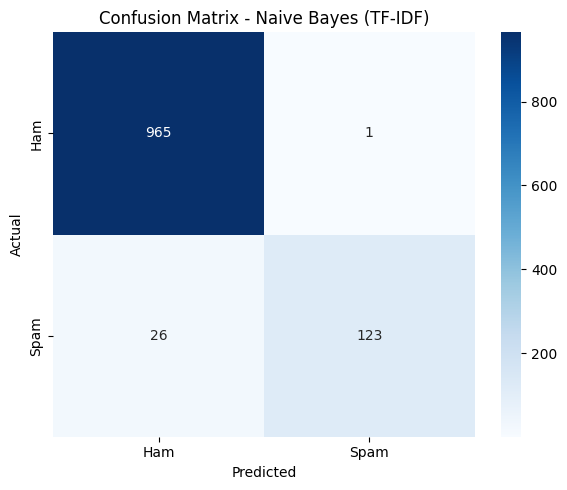

In [42]:
# Cell 8: Error Analysis (False Negatives) & Confusion Matrix
# Identifies missed spam messages (critical security metric).
# Visualizes prediction breakdown for detailed performance review.

false_negatives = []
for i in range(len(y_test)):
    if y_test.iloc[i] == 1 and y_pred_nb[i] == 0:
        false_negatives.append(X_test.iloc[i])

print(f"🔍 False Negatives (Missed Spam): {len(false_negatives)}")
print(f"False Negative Rate: {len(false_negatives)/sum(y_test)*100:.2f}%")
print("Sample missed messages:")
for i, msg in enumerate(false_negatives[:5], 1):
    print(f"{i}. {msg}")

cm = confusion_matrix(y_test, y_pred_nb)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Ham', 'Spam'], yticklabels=['Ham', 'Spam'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Naive Bayes (TF-IDF)')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()

In [43]:
# Cell 9: PCA Dimensionality Reduction Experiment
# Applies PCA to reduce TF-IDF features, followed by MinMaxScaler for NB compatibility.
from sklearn.decomposition import PCA
from sklearn.preprocessing import MinMaxScaler

print("=== ADDITIONAL ABLATION: PCA Dimensionality Reduction ===")
# Reduce to 50 components to retain more variance while testing dimensionality reduction
pca = PCA(n_components=50, random_state=42)
X_train_pca = pca.fit_transform(X_train_tfidf.toarray())
X_test_pca = pca.transform(X_test_tfidf.toarray())

print(f"Features reduced from {X_train_tfidf.shape[1]} to {X_train_pca.shape[1]}")
print(f"Explained variance ratio: {pca.explained_variance_ratio_.sum():.4f}")

# Scale to [0, 1] to satisfy MultinomialNB non-negativity constraint
scaler = MinMaxScaler()
X_train_pca_scaled = scaler.fit_transform(X_train_pca)
X_test_pca_scaled = scaler.transform(X_test_pca)

nb_pca = MultinomialNB(alpha=1.0)
nb_pca.fit(X_train_pca_scaled, y_train)
y_pred_pca = nb_pca.predict(X_test_pca_scaled)

print(f"\nNB + PCA (50 components) Accuracy: {accuracy_score(y_test, y_pred_pca):.4f}")
print(f"NB + PCA (50 components) F1-Score:  {f1_score(y_test, y_pred_pca):.4f}")
print("PCA experiment complete.")

=== ADDITIONAL ABLATION: PCA Dimensionality Reduction ===
Features reduced from 3000 to 50
Explained variance ratio: 0.1967

NB + PCA (50 components) Accuracy: 0.8664
NB + PCA (50 components) F1-Score:  0.0000
PCA experiment complete.


In [44]:
# Cell 10: Enhanced Error Analysis (Focus on False Negatives)
# Critical for spam detection: missing spam is more costly than false alarms.
from sklearn.metrics import confusion_matrix

print("\n=== DETAILED ERROR ANALYSIS ===")
tn, fp, fn, tp = confusion_matrix(y_test, y_pred_nb).ravel()

print(f"True Negatives (Correct Ham):     {tn}")
print(f"False Positives (Ham -> Spam):    {fp}")
print(f"False Negatives (Spam -> Ham):    {fn} [CRITICAL METRIC]")
print(f"True Positives (Correct Spam):    {tp}")

print(f"\nKey Security Metrics:")
print(f"Recall (Spam Detection Rate): {tp/(tp+fn):.4f}")
print(f"Precision (Prediction Accuracy): {tp/(tp+fp):.4f}")
print(f"False Negative Rate: {fn/(fn+tp):.4f}")

print(f"\nSample Missed Spam Messages (Top 5):")
for i, msg in enumerate(false_negatives[:5], 1):
    print(f"{i}. {msg}")


=== DETAILED ERROR ANALYSIS ===
True Negatives (Correct Ham):     965
False Positives (Ham -> Spam):    1
False Negatives (Spam -> Ham):    26 [CRITICAL METRIC]
True Positives (Correct Spam):    123

Key Security Metrics:
Recall (Spam Detection Rate): 0.8255
Precision (Prediction Accuracy): 0.9919
False Negative Rate: 0.1745

Sample Missed Spam Messages (Top 5):
1. freemsg hey darl week word back like fun still tb ok xxx std chg send rcv
2. guess somebodi know secretli fanci wanna find give us call landlin datebox essexcm xn p min
3. talk sexi make new friend fall love world discreet text date servic text vip see could meet
4. hi ur lookin sauci daytim fun wiv busti marri woman free next week chat sort time janinexx call minmobsmorelkpobox hp fl
5. ringtonek


In [45]:
# Cell 11: Final Results Summary Table (Matches Paper Format)
# Consolidates all experiments into a single comparison table for the report.
results_data = []

# 1. Main Result: NB + TF-IDF
results_data.append({
    'Model': 'Naive Bayes', 'Features': 'TF-IDF',
    'Accuracy': accuracy_score(y_test, y_pred_nb),
    'Precision': precision_score(y_test, y_pred_nb),
    'Recall': recall_score(y_test, y_pred_nb),
    'F1-Score': f1_score(y_test, y_pred_nb)
})

# 2. Baseline: NB + BoW
y_pred_bow_final = nb_bow.predict(X_test_bow)
results_data.append({
    'Model': 'Naive Bayes', 'Features': 'BoW',
    'Accuracy': accuracy_score(y_test, y_pred_bow_final),
    'Precision': precision_score(y_test, y_pred_bow_final),
    'Recall': recall_score(y_test, y_pred_bow_final),
    'F1-Score': f1_score(y_test, y_pred_bow_final)
})

# 3. PCA Experiment
results_data.append({
    'Model': 'Naive Bayes', 'Features': 'PCA(50)',
    'Accuracy': accuracy_score(y_test, y_pred_pca),
    'Precision': precision_score(y_test, y_pred_pca),
    'Recall': recall_score(y_test, y_pred_pca),
    'F1-Score': f1_score(y_test, y_pred_pca)
})

# 4. Other Models
other_models = {
    'SVM': SVC(kernel='linear', class_weight='balanced', random_state=42, probability=True),
    'Decision Tree': DecisionTreeClassifier(class_weight='balanced', random_state=42),
    'KNN': KNeighborsClassifier(n_neighbors=5)
}

for name, model in other_models.items():
    model.fit(X_train_tfidf, y_train)
    preds = model.predict(X_test_tfidf)
    results_data.append({
        'Model': name, 'Features': 'TF-IDF',
        'Accuracy': accuracy_score(y_test, preds),
        'Precision': precision_score(y_test, preds),
        'Recall': recall_score(y_test, preds),
        'F1-Score': f1_score(y_test, preds)
    })

# Create and display DataFrame
results_df = pd.DataFrame(results_data)
print("\n=== FINAL RESULTS SUMMARY (Paper Table Format) ===")
print(results_df.to_string(index=False))
results_df.to_csv('final_results_summary.csv', index=False)
print("\nResults table saved to 'final_results_summary.csv'")

C:\Users\AL-FAJR\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])



=== FINAL RESULTS SUMMARY (Paper Table Format) ===
        Model Features  Accuracy  Precision   Recall  F1-Score
  Naive Bayes   TF-IDF  0.975785   0.991935 0.825503  0.901099
  Naive Bayes      BoW  0.982063   0.938776 0.926174  0.932432
  Naive Bayes  PCA(50)  0.866368   0.000000 0.000000  0.000000
          SVM   TF-IDF  0.982960   0.957746 0.912752  0.934708
Decision Tree   TF-IDF  0.956054   0.794118 0.906040  0.846395
          KNN   TF-IDF  0.920179   1.000000 0.402685  0.574163

Results table saved to 'final_results_summary.csv'
